# Sample Mean and Sample Covariance Matrix

Given a dataset $\mathcal{D} = \{\mathbf{x}_n\}_{n=1}^N$ of $N$ data vectors, $\mathbf{x}_n \in \mathbb{R}^d$.

## Sample Mean

$$\boldsymbol{\mu} = \frac{1}{N} \sum_{n=1}^{N} \mathbf{x}_n$$

Each component: $\mu_i = \frac{1}{N} \sum_{n=1}^{N} x_{ni}$

## Sample Covariance Matrix

$$\Sigma = \frac{1}{N-1} \sum_{n=1}^{N} (\mathbf{x}_n - \boldsymbol{\mu})(\mathbf{x}_n - \boldsymbol{\mu})^\top = E\!\left[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^\top\right]$$

$$\Sigma = \begin{bmatrix} \sigma_1^2 & \sigma_{12} & \cdots & \sigma_{1d} \\ \sigma_{21} & \sigma_2^2 & \cdots & \sigma_{2d} \\ \vdots & & \ddots & \vdots \\ \sigma_{d1} & \sigma_{d2} & \cdots & \sigma_d^2 \end{bmatrix}$$

- **Sample variance** of the $i$-th attribute: $\displaystyle\sigma_i^2 = \frac{1}{N-1}\sum_{n=1}^{N}(x_{ni} - \mu_i)^2$
- **Sample covariance** of the $i$-th and $j$-th attributes: $\displaystyle\sigma_{ij} = \frac{1}{N-1}\sum_{n=1}^{N}(x_{ni} - \mu_i)(x_{nj} - \mu_j)$

> The $N-1$ denominator (Bessel's correction) makes $\Sigma$ an **unbiased** estimator of the true covariance.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## Dataset

A small $d=3$ dataset ($N=8$ samples) to compute everything step by step:

| $n$ | $x_1$ (height cm) | $x_2$ (weight kg) | $x_3$ (age yr) |
|---|---|---|---|
| 1 | 160 | 55 | 25 |
| 2 | 175 | 80 | 32 |
| 3 | 168 | 62 | 28 |
| 4 | 180 | 85 | 35 |
| 5 | 155 | 50 | 22 |
| 6 | 172 | 70 | 30 |
| 7 | 165 | 60 | 27 |
| 8 | 178 | 78 | 33 |

In [9]:
import pandas as pd

# Dataset: N=8 samples, d=3 features
# Each row is one data vector x_n = [height, weight, age]
X = np.array([
    [160, 55, 25],
    [175, 80, 32],
    [168, 62, 28],
    [180, 85, 35],
    [155, 50, 22],
    [172, 70, 30],
    [165, 60, 27],
    [178, 78, 33],
], dtype=float)

N, d = X.shape
features = ['height (cm)', 'weight (kg)', 'age (yr)']
print(f"Dataset shape: N={N} samples, d={d} features\n")

df_data = pd.DataFrame(X, columns=features, index=pd.RangeIndex(1, N+1, name='n'))
display(df_data.astype(int))

Dataset shape: N=8 samples, d=3 features



,height (cm),weight (kg),age (yr)
n,,,
1,160,55,25
2,175,80,32
3,168,62,28
4,180,85,35
5,155,50,22
6,172,70,30
7,165,60,27
8,178,78,33


## Step 1 — Sample Mean

$$\boldsymbol{\mu} = \frac{1}{N} \sum_{n=1}^{N} \mathbf{x}_n$$

In [10]:
# Manual summation (column sums / N)
col_sums = X.sum(axis=0)
mu = col_sums / N

df_mu = pd.DataFrame(
    {'Σ xₙ': col_sums, 'N': [N]*d, 'μᵢ = Σxₙ/N': mu},
    index=pd.Index(features, name='feature')
).round(4)
display(df_mu)

# Verify with numpy
assert np.allclose(mu, X.mean(axis=0))
print("Matches np.mean: True")

,Σ xₙ,N,μᵢ = Σxₙ/N
feature,,,
height (cm),1353.0,8,169.125
weight (kg),540.0,8,67.500
age (yr),232.0,8,29.000


Matches np.mean: True


## Step 2 — Centre the Data

Subtract the sample mean from each data vector:

$$\tilde{\mathbf{x}}_n = \mathbf{x}_n - \boldsymbol{\mu}$$

The centred data matrix $\tilde{X}$ has shape $(N \times d)$.

In [11]:
X_c = X - mu   # centred data matrix, shape (N, d)

print("Centred data  X̃  (xₙ − μ):\n")
col_names = [f'x̃_{i+1} ({f.split()[0]})' for i, f in enumerate(features)]
df_centred = pd.DataFrame(X_c, columns=col_names, index=pd.RangeIndex(1, N+1, name='n'))
display(df_centred.round(4))

print("\nColumn means of X̃ (should be ≈ 0):")
means = pd.Series(X_c.mean(axis=0), index=col_names)
display(means.map(lambda v: f"{v:.2e}").to_frame(name='mean').T)

Centred data  X̃  (xₙ − μ):



,x̃_1 (height),x̃_2 (weight),x̃_3 (age)
n,,,
1,-9.125,-12.5,-4.0
2,5.875,12.5,3.0
3,-1.125,-5.5,-1.0
4,10.875,17.5,6.0
5,-14.125,-17.5,-7.0
6,2.875,2.5,1.0
7,-4.125,-7.5,-2.0
8,8.875,10.5,4.0



Column means of X̃ (should be ≈ 0):


,x̃_1 (height),x̃_2 (weight),x̃_3 (age)
mean,0.00e+00,0.00e+00,0.00e+00


## Step 3 — Sample Covariance Matrix

$$\Sigma = \frac{1}{N-1} \sum_{n=1}^{N} (\mathbf{x}_n - \boldsymbol{\mu})(\mathbf{x}_n - \boldsymbol{\mu})^\top = \frac{1}{N-1} \tilde{X}^\top \tilde{X}$$

Each entry: $\sigma_{ij} = \dfrac{1}{N-1} \displaystyle\sum_{n=1}^{N} (x_{ni} - \mu_i)(x_{nj} - \mu_j)$

In [12]:
# Method 1: outer-product sum  Σ = (1/(N-1)) X̃ᵀ X̃
Sigma_outer = (X_c.T @ X_c) / (N - 1)

# Method 2: np.cov (uses N-1 by default)
Sigma_np = np.cov(X.T)

print(f"Sample covariance matrix  Σ  ({d}×{d}), computed via X̃ᵀX̃ / (N−1):\n")
df_cov = pd.DataFrame(Sigma_outer, index=features, columns=features).round(4)
display(df_cov)

print(f"\nMatches np.cov: {np.allclose(Sigma_outer, Sigma_np)}")
print(f"Symmetric:      {np.allclose(Sigma_outer, Sigma_outer.T)}")

print("\nIndividual entries:")
entries = {
    'σ²₁  (height var)':        Sigma_outer[0,0],
    'σ²₂  (weight var)':        Sigma_outer[1,1],
    'σ²₃  (age var)':           Sigma_outer[2,2],
    'σ₁₂  (height-weight cov)': Sigma_outer[0,1],
    'σ₁₃  (height-age cov)':    Sigma_outer[0,2],
    'σ₂₃  (weight-age cov)':    Sigma_outer[1,2],
}
df_entries = pd.DataFrame(entries.items(), columns=['Entry', 'Value']).round(4)
display(df_entries)

Sample covariance matrix  Σ  (3×3), computed via X̃ᵀX̃ / (N−1):



,height (cm),weight (kg),age (yr)
height (cm),77.2679,108.9286,38.0000
weight (kg),108.9286,161.1429,54.2857
age (yr),38.0000,54.2857,18.8571



Matches np.cov: True
Symmetric:      True

Individual entries:


,Entry,Value
0,σ²₁ (height var),77.2679
1,σ²₂ (weight var),161.1429
2,σ²₃ (age var),18.8571
3,σ₁₂ (height-weight cov),108.9286
4,σ₁₃ (height-age cov),38.0000
5,σ₂₃ (weight-age cov),54.2857


## Bessel's Correction: N vs N−1

Why divide by $N-1$ and not $N$?

- Dividing by $N$ gives the **biased** (MLE) estimate — systematically underestimates the true variance
- Dividing by $N-1$ gives the **unbiased** estimate: $E[\hat{\Sigma}] = \Sigma$

Below we show the bias shrinks as $N$ grows.

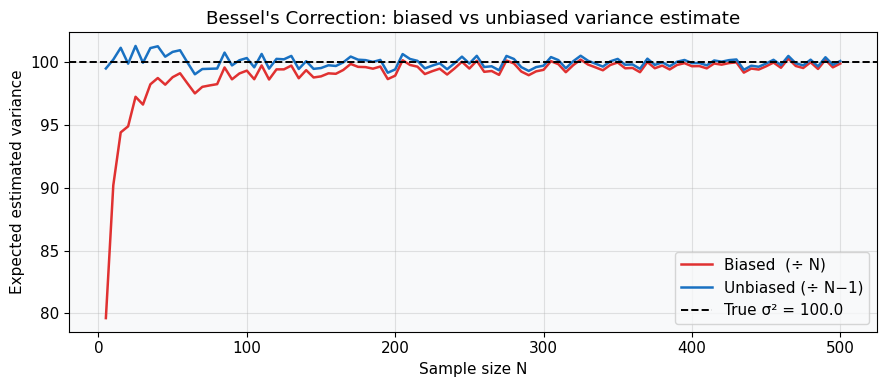

In [6]:
true_var = 100.0   # e.g. σ² of Normal(0, 10²)
rng = np.random.default_rng(42)
sample_sizes = np.arange(5, 501, 5)

biased_vars   = []
unbiased_vars = []

for n in sample_sizes:
    trials = [rng.normal(0, 10, size=n) for _ in range(500)]
    biased_vars.append(np.mean([s.var(ddof=0) for s in trials]))     # divide by N
    unbiased_vars.append(np.mean([s.var(ddof=1) for s in trials]))   # divide by N-1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample_sizes, biased_vars,   color='#e03131', lw=1.8, label='Biased  (÷ N)')
ax.plot(sample_sizes, unbiased_vars, color='#1971c2', lw=1.8, label='Unbiased (÷ N−1)')
ax.axhline(true_var, color='black', lw=1.4, ls='--', label=f'True σ² = {true_var}')
ax.set_xlabel('Sample size N')
ax.set_ylabel('Expected estimated variance')
ax.set_title("Bessel's Correction: biased vs unbiased variance estimate")
ax.legend()
plt.tight_layout()
plt.show()

## Visualisation: Mean, Variance, and Covariance Matrix

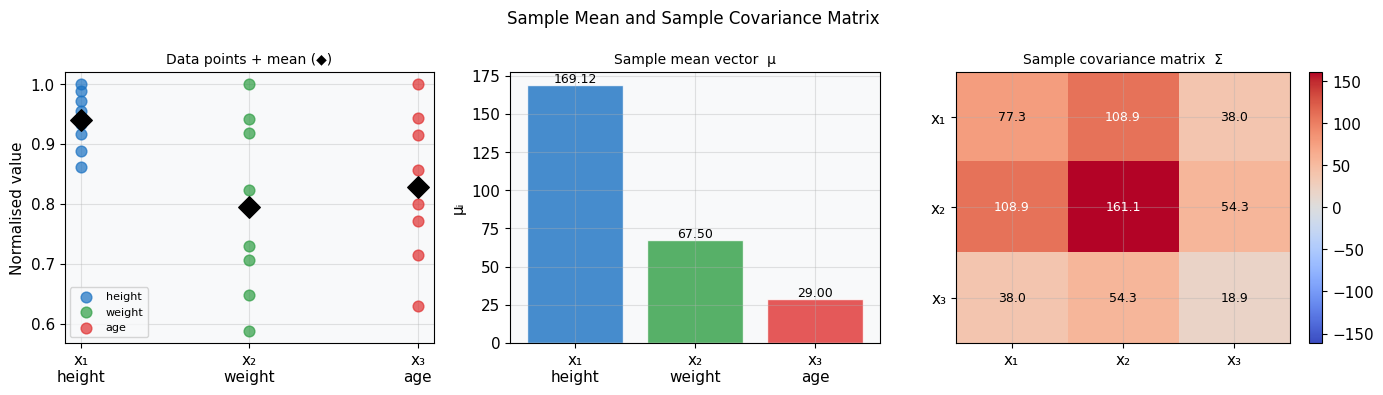

In [7]:
colors = ['#1971c2', '#2f9e44', '#e03131']
short = ['x₁\nheight', 'x₂\nweight', 'x₃\nage']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Left: data scatter (each pair represented as strip plots)
ax = axes[0]
for j, (col, lbl) in enumerate(zip(colors, features)):
    ax.scatter([j]*N, X[:, j] / X[:, j].max(),  # normalise to [0,1] for overlay
               color=col, s=60, alpha=0.7, zorder=3, label=lbl.split()[0])
    ax.scatter([j], mu[j] / X[:, j].max(),
               color='black', s=120, marker='D', zorder=4)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(short)
ax.set_ylabel('Normalised value')
ax.set_title('Data points + mean (◆)', fontsize=10)
ax.legend(fontsize=8)

# ── Middle: mean vector bar chart
ax2 = axes[1]
bars = ax2.bar(short, mu, color=colors, alpha=0.8, edgecolor='white')
for bar, v in zip(bars, mu):
    ax2.text(bar.get_x() + bar.get_width()/2, v + max(mu)*0.01,
             f'{v:.2f}', ha='center', fontsize=9)
ax2.set_title('Sample mean vector  μ', fontsize=10)
ax2.set_ylabel('μᵢ')

# ── Right: covariance matrix heatmap
ax3 = axes[2]
vmax = np.abs(Sigma_outer).max()
im = ax3.imshow(Sigma_outer, cmap='coolwarm', aspect='auto', vmin=-vmax, vmax=vmax)
ax3.set_xticks([0,1,2]); ax3.set_xticklabels(['x₁','x₂','x₃'])
ax3.set_yticks([0,1,2]); ax3.set_yticklabels(['x₁','x₂','x₃'])
ax3.set_title('Sample covariance matrix  Σ', fontsize=10)
for i in range(d):
    for j in range(d):
        txt_col = 'white' if abs(Sigma_outer[i,j]) > vmax*0.55 else 'black'
        ax3.text(j, i, f'{Sigma_outer[i,j]:.1f}',
                 ha='center', va='center', fontsize=9, color=txt_col)
plt.colorbar(im, ax=ax3, fraction=0.046)

plt.suptitle('Sample Mean and Sample Covariance Matrix', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

| Quantity | Formula | numpy |
|---|---|---|
| **Sample mean** | $\boldsymbol{\mu} = \frac{1}{N}\sum_{n=1}^N \mathbf{x}_n$ | `X.mean(axis=0)` |
| **Centred data** | $\tilde{X} = X - \boldsymbol{\mu}$ | `X - mu` |
| **Sample covariance** | $\Sigma = \frac{1}{N-1}\tilde{X}^\top\tilde{X}$ | `np.cov(X.T)` |
| **Sample variance** | $\sigma_i^2 = \Sigma_{ii}$ | `np.diag(np.cov(X.T))` |
| **Sample covariance** | $\sigma_{ij} = \Sigma_{ij}$ | off-diagonal of `np.cov(X.T)` |
| **Symmetry** | $\sigma_{ij} = \sigma_{ji}$ | always holds |
| **Bessel's correction** | divide by $N-1$, not $N$ | `ddof=1` in numpy |